In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install imagededup opencv-python matplotlib tqdm scikit-learn tensorflow
!pip install albumentations opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.6/318.6 kB 11.6 MB/s eta 0:00:00


In [3]:
import os
import cv2

import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths
Final_data_path = "/content/drive/MyDrive/Final_Dataset"

class_names = ["Healthy", "Rot_leaf", "Spot_leaf"]
samples_per_class = 3
print(" Final dataset:", os.listdir(Final_data_path))

 Final dataset: ['Rot_leaf', 'Spot_leaf', 'Healthy']


In [4]:
import os

print("📊 FINAL DATASET SUMMARY")
print("=" * 30)

total_images = 0

# Check each class folder
for class_name in os.listdir(Final_data_path):
    class_path = os.path.join(Final_data_path, class_name)

    if os.path.isdir(class_path):
        # Count image files in this class
        image_count = len([f for f in os.listdir(class_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])

        print(f"{class_name}: {image_count} images")
        total_images += image_count

print("=" * 30)
print(f"TOTAL: {total_images} images")

📊 FINAL DATASET SUMMARY
Rot_leaf: 1337 images
Spot_leaf: 3406 images
Healthy: 5427 images
TOTAL: 10170 images


In [5]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split


# Paths
Final_data_path = "/content/drive/MyDrive/Final_Dataset"
output_dir = "/content/Final_split"

# Classes (from your final dataset)
classes = ["Healthy", "Rot_leaf", "Spot_leaf"] # Removed "Unknown"

# Clean old split if exists
shutil.rmtree(output_dir, ignore_errors=True)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split ratio
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

random.seed(42)  # reproducibility

for cls in classes:
    class_dir = os.path.join(Final_data_path, cls)

    if not os.path.exists(class_dir):
        print(f"⚠️ Skipping {cls} because folder not found")
        continue

    all_files = [f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # First split: train vs temp (val+test)
    train_files, temp_files = train_test_split(
        all_files, test_size=1-train_ratio, random_state=42
    )

    # Second split: val vs test
    val_files, test_files = train_test_split(
        temp_files, test_size=test_ratio/(val_ratio+test_ratio), random_state=42
    )

    # Copy files to respective directories
    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "train", cls, f)
        shutil.copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "val", cls, f)
        shutil.copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "test", cls, f)
        shutil.copy2(src, dst)

    print(f"✅ {cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

print("\n🎯 Dataset split completed!")

✅ Healthy: 3798 train, 814 val, 815 test
✅ Rot_leaf: 935 train, 201 val, 201 test
✅ Spot_leaf: 2384 train, 511 val, 511 test

🎯 Dataset split completed!


In [6]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

# ===============================
# Data Transforms
# ===============================
# Training transformations with augmentation
train_transform = transforms.Compose([
    transforms.Resize((160, 160)),             # Resize to smaller size to save VRAM
    transforms.RandomResizedCrop(128),        # Random crop for augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation & Test transformations (deterministic)
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),            # Match training crop size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ===============================
# Datasets
# ===============================
data_dir = "/content/Final_split"

train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(root=f"{data_dir}/val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=f"{data_dir}/test",  transform=val_test_transform)

# ===============================
# Weighted Sampling to fix class imbalance
# ===============================
class_counts = torch.tensor([len([1 for _, label in train_dataset.imgs if label == i])
                             for i in range(len(train_dataset.classes))], dtype=torch.float)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for _, label in train_dataset.imgs]

sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

# ===============================
# DataLoaders
# ===============================
batch_size = 16  # Reduce to 8 if OOM occurs

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

# ===============================
# Dataset Info
# ===============================
print(f"Classes: {train_dataset.classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Classes: ['Healthy', 'Rot_leaf', 'Spot_leaf']
Train samples: 7117
Validation samples: 1526
Test samples: 1527


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from tqdm import tqdm
import time
import copy

In [8]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Training function
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Store metrics
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloader, desc=f'{phase} epoch {epoch}'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Store history
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.cpu().numpy())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.cpu().numpy())

            # Deep copy the model if it's the best validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Return model and history
    history = {
        'train_loss': train_loss_history,
        'train_acc': train_acc_history,
        'val_loss': val_loss_history,
        'val_acc': val_acc_history
    }

    return model, history

Using device: cuda


In [9]:
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluating'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

def plot_confusion_matrix(y_true, y_pred, classes, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # Print classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=classes))

    return cm

def plot_training_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot loss
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{model_name} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot accuracy
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_title(f'{model_name} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [10]:
def plot_roc_curve(y_true, y_pred_proba, classes, model_name):
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i, class_name in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_true, y_pred_proba[:, i], pos_label=i)
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(classes):
        plt.plot(fpr[i], tpr[i], label=f'{class_name} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# -----------------------------
# Image transformations
# -----------------------------
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),  # resize all images
        transforms.RandomHorizontalFlip(),  # data augmentation
        transforms.RandomRotation(20),
        transforms.ToTensor(),  # convert to tensor
        transforms.Normalize([0.485, 0.456, 0.406],  # normalize like ImageNet
                             [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

# -----------------------------
# Load datasets
# -----------------------------
data_dir = "/content/Final_split"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=data_transforms["train"])
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=data_transforms["val"])
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=data_transforms["test"])

# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# -----------------------------
# Class mapping
# -----------------------------
print("Classes:", train_dataset.classes)   # ['Healthy', 'Rot_leaf', 'Spot_leaf']
print("Class to index:", train_dataset.class_to_idx)

Classes: ['Healthy', 'Rot_leaf', 'Spot_leaf']
Class to index: {'Healthy': 0, 'Rot_leaf': 1, 'Spot_leaf': 2}


In [12]:
import time, copy, os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# device if not defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def train_model(model, dataloaders, criterion, optimizer, scheduler=None, num_epochs=10, device=device):
    """
    dataloaders: dict with keys 'train' and 'val' pointing to DataLoader objects
    returns: best_model (weights restored), history dict
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        for phase in ['train', 'val']:
            is_train = (phase == 'train')
            if is_train:
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            dataset_size = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase} epoch {epoch+1}", leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(is_train):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if is_train:
                        loss.backward()
                        optimizer.step()

                batch_size = inputs.size(0)
                running_loss += loss.item() * batch_size
                running_corrects += (preds == labels).sum().item()
                dataset_size += batch_size

            if is_train and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects / dataset_size

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {int(time_elapsed//60)}m {int(time_elapsed%60)}s. Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history


def evaluate_model_probs(model, dataloader, device=device):
    """
    Returns y_true (list), y_pred (list), y_score (np.array: n_samples x n_classes)
    """
    model.eval()
    y_true = []
    y_pred = []
    y_score = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)  # logits
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_score.append(probs.cpu().numpy())

    y_score = np.vstack(y_score)  # shape (n_samples, n_classes)
    return np.array(y_true), np.array(y_pred), y_score


def plot_confusion_matrix(y_true, y_pred, classes, title=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('True')
    plt.xlabel('Pred')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=classes))


def plot_training_history(history, model_name="model"):
    plt.figure(figsize=(12,4))
    # loss
    plt.subplot(1,2,1)
    plt.plot(history['train_loss'], label='train_loss')
    plt.plot(history['val_loss'], label='val_loss')
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.legend()
    # acc
    plt.subplot(1,2,2)
    plt.plot(history['train_acc'], label='train_acc')
    plt.plot(history['val_acc'], label='val_acc')
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes, title="ROC"):
    """
    y_true: array-like of shape (n_samples,)
    y_score: array-like of shape (n_samples, n_classes) -- probabilities
    """
    n_classes = len(classes)
    y_true_b = label_binarize(y_true, classes=list(range(n_classes)))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    plt.figure(figsize=(7,6))
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_b[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

Device: cuda


Epoch 1/12


train Loss: 0.6885 Acc: 0.7330


val Loss: 0.4626 Acc: 0.8218

Epoch 2/12


train Loss: 0.4822 Acc: 0.8067


val Loss: 0.4096 Acc: 0.8381

Epoch 3/12


...

val Loss: 0.2324 Acc: 0.9181

Epoch 11/12


train Loss: 0.2201 Acc: 0.9202


val Loss: 0.2284 Acc: 0.9194

Epoch 12/12


train Loss: 0.2268 Acc: 0.9178


val Loss: 0.2272 Acc: 0.9201

Training complete in 4m 33s. Best val Acc: 0.9201


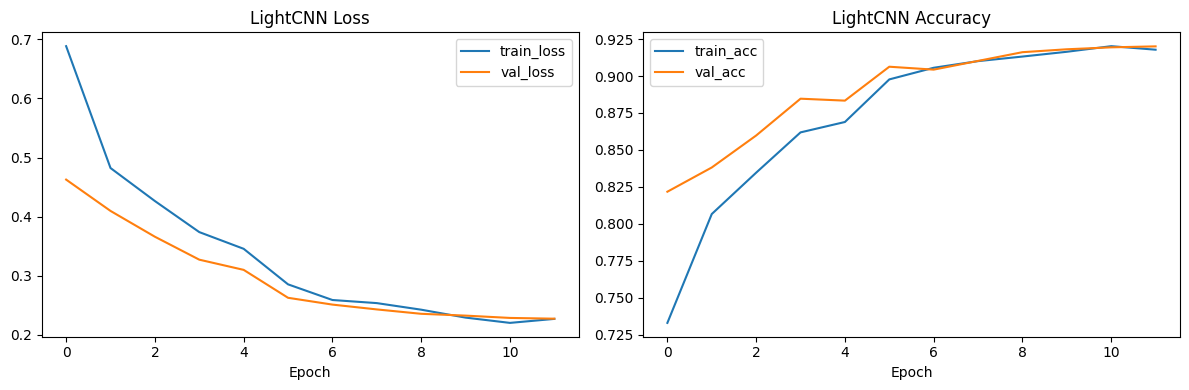

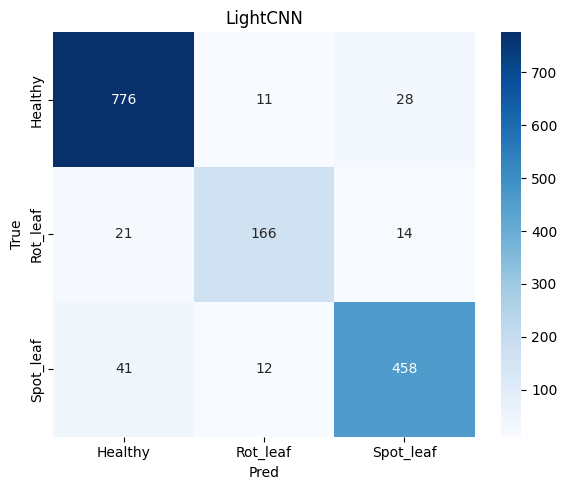

              precision    recall  f1-score   support

     Healthy       0.93      0.95      0.94       815
    Rot_leaf       0.88      0.83      0.85       201
   Spot_leaf       0.92      0.90      0.91       511

    accuracy                           0.92      1527
   macro avg       0.91      0.89      0.90      1527
weighted avg       0.92      0.92      0.92      1527



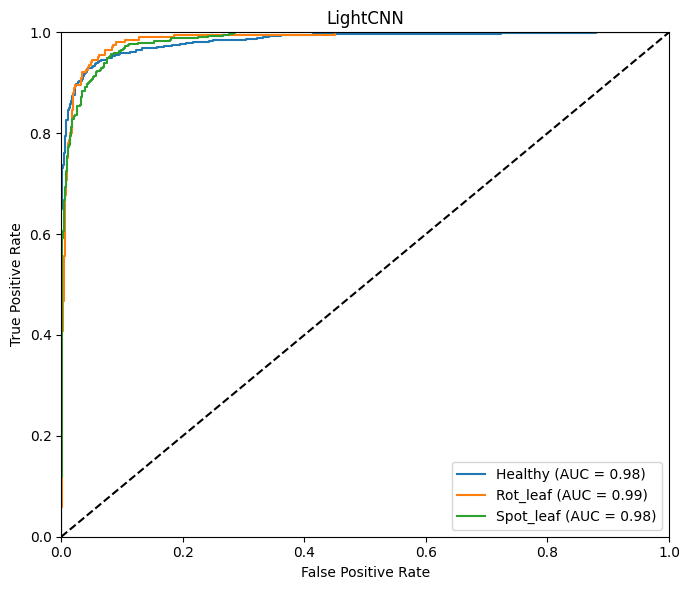

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# Simple CNN Model (Light CNN)
# -----------------------------
class LightCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(LightCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 112x112

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 56x56

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# -----------------------------
# Create model, loss, optimizer
# -----------------------------
num_classes = len(train_dataset.classes)  # should be 3
model_light = LightCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_light.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Create the dataloaders dictionary
dataloaders = {
    'train': train_loader,
    'val': val_loader,
    'test': test_loader
}

# -----------------------------
# Train model
# -----------------------------
model_light, history_light = train_model(
    model_light,
    dataloaders,
    criterion,
    optimizer,
    scheduler,
    num_epochs=12,
    device=device
)

# -----------------------------
# Plot training history
# -----------------------------
plot_training_history(history_light, "LightCNN")

# -----------------------------
# Evaluate on test set
# -----------------------------
test_labels, test_preds, test_scores = evaluate_model_probs(model_light, dataloaders["test"])
cm = plot_confusion_matrix(test_labels, test_preds, train_dataset.classes, "LightCNN")
plot_multiclass_roc(test_labels, test_scores, train_dataset.classes, "LightCNN")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 119MB/s] 


Epoch 1/12


train Loss: 0.2502 Acc: 0.9118


...

val Loss: 0.0404 Acc: 0.9889

Epoch 11/12


train Loss: 0.0064 Acc: 0.9982


val Loss: 0.0399 Acc: 0.9902

Epoch 12/12


train Loss: 0.0076 Acc: 0.9980


val Loss: 0.0395 Acc: 0.9902

Training complete in 5m 38s. Best val Acc: 0.9902


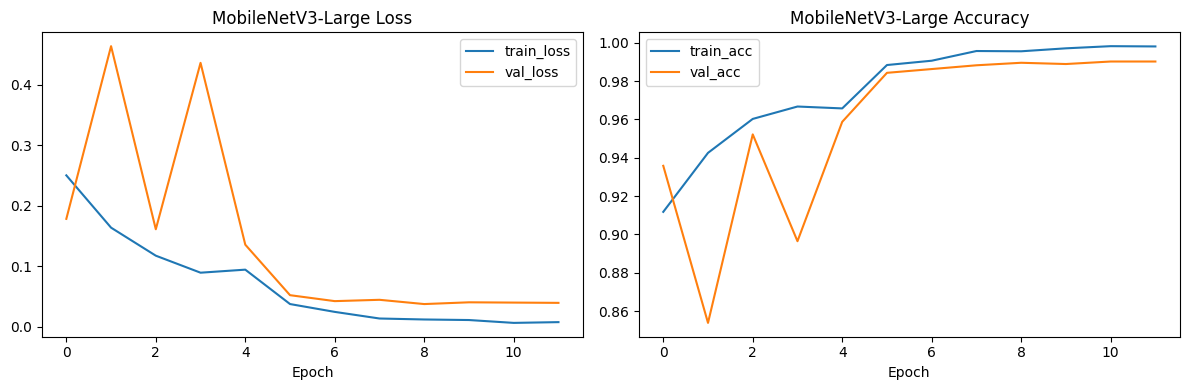

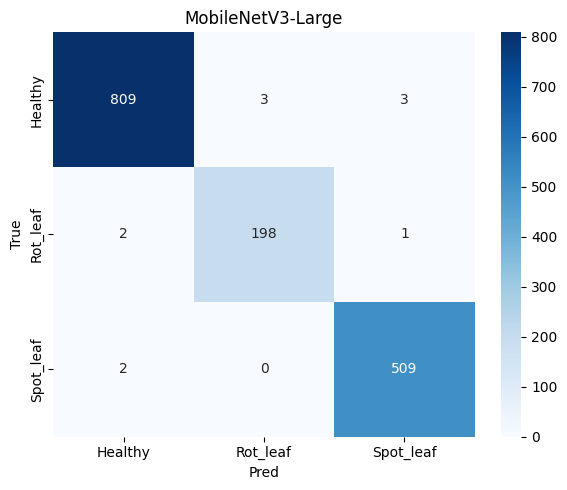

              precision    recall  f1-score   support

     Healthy       1.00      0.99      0.99       815
    Rot_leaf       0.99      0.99      0.99       201
   Spot_leaf       0.99      1.00      0.99       511

    accuracy                           0.99      1527
   macro avg       0.99      0.99      0.99      1527
weighted avg       0.99      0.99      0.99      1527



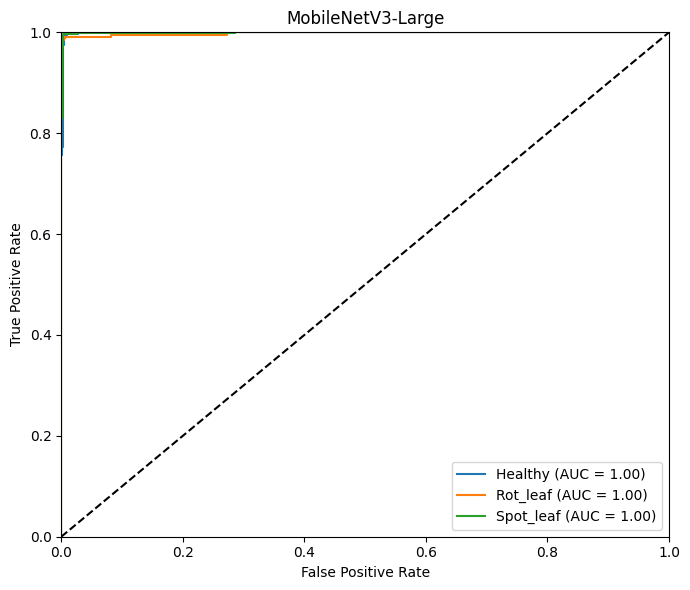

In [15]:
from torchvision import models

# -----------------------------
# MobileNetV3-Large Model
# -----------------------------
def get_mobilenet_v3(num_classes):
    model = models.mobilenet_v3_large(pretrained=True)
    in_features = model.classifier[3].in_features  # final linear layer
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model.to(device)

# Create model
model_mobilenet = get_mobilenet_v3(len(train_dataset.classes))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mobilenet.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Train
model_mobilenet, history_mobilenet = train_model(
    model_mobilenet,
    dataloaders,
    criterion,
    optimizer,
    scheduler,
    num_epochs=12,
    device=device
)

# Plot
plot_training_history(history_mobilenet, "MobileNetV3-Large")

# Evaluate
test_labels, test_preds, test_scores = evaluate_model_probs(model_mobilenet, dataloaders["test"])
plot_confusion_matrix(test_labels, test_preds, train_dataset.classes, "MobileNetV3-Large")
plot_multiclass_roc(test_labels, test_scores, train_dataset.classes, "MobileNetV3-Large")

In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.utils.data import Subset, DataLoader

k_folds = 10
results = {}

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

dataset = train_dataset  # full dataset used for training

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f"\n📌 Fold {fold+1}/{k_folds}")
    print("-" * 40)

    # Create subset loaders
    train_subset = Subset(dataset, train_idx)
    val_subset   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=32, shuffle=False)

    dataloaders_kfold = {
        "train": train_loader,
        "val": val_loader
    }

    # Reinitialize model for this fold
    model = get_mobilenet_v3(len(dataset.classes))

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    # Train model
    model, history = train_model(
        model,
        dataloaders_kfold,
        criterion,
        optimizer,
        scheduler,
        num_epochs=12,
        device=device
    )

    # Evaluate
    val_labels, val_preds, val_scores = evaluate_model_probs(model, val_loader)

    # Calculate fold metrics
    acc = (val_labels == val_preds).mean()
    precision = precision_score(val_labels, val_preds, average="macro")
    recall = recall_score(val_labels, val_preds, average="macro")
    f1 = f1_score(val_labels, val_preds, average="macro")

    print(f"✔ Fold {fold+1} Metrics:")
    print(f"   Accuracy : {acc:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall   : {recall:.4f}")
    print(f"   F1 Score : {f1:.4f}\n")

    # Save fold metrics
    results[fold] = {
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ======================================
# Print overall results
# ======================================
print("========== K-FOLD METRICS ==========")

avg_acc = sum(r["acc"] for r in results.values()) / k_folds
avg_precision = sum(r["precision"] for r in results.values()) / k_folds
avg_recall = sum(r["recall"] for r in results.values()) / k_folds
avg_f1 = sum(r["f1"] for r in results.values()) / k_folds

for k, r in results.items():
    print(f"Fold {k+1}: "
          f"Acc={r['acc']:.4f}, "
          f"Precision={r['precision']:.4f}, "
          f"Recall={r['recall']:.4f}, "
          f"F1={r['f1']:.4f}")

print("\n🔥 AVERAGE SCORES ACROSS 10 FOLDS 🔥")
print(f"Accuracy : {avg_acc:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall   : {avg_recall:.4f}")
print(f"F1 Score : {avg_f1:.4f}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



📌 Fold 1/10
----------------------------------------
Epoch 1/12


train Loss: 0.2700 Acc: 0.9009


val Loss: 0.2942 Acc: 0.9199

Epoch 2/12


train Loss: 0.1799 Acc: 0.9349


...

train Loss: 0.0150 Acc: 0.9948


val Loss: 0.0466 Acc: 0.9873

Epoch 12/12


train Loss: 0.0122 Acc: 0.9956


val Loss: 0.0543 Acc: 0.9817

Training complete in 6m 47s. Best val Acc: 0.9873


✔ Fold 10 Metrics:
   Accuracy : 0.9831
   Precision: 0.9756
   Recall   : 0.9713
   F1 Score : 0.9734

========== K-FOLD METRICS ==========
Fold 1: Acc=0.9902, Precision=0.9875, Recall=0.9844, F1=0.9860
Fold 2: Acc=0.9944, Precision=0.9960, Recall=0.9877, F1=0.9917
Fold 3: Acc=0.9831, Precision=0.9835, Recall=0.9746, F1=0.9788
Fold 4: Acc=0.9958, Precision=0.9974, Recall=0.9960, F1=0.9967
Fold 5: Acc=0.9874, Precision=0.9852, Recall=0.9886, F1=0.9869
Fold 6: Acc=0.9775, Precision=0.9691, Recall=0.9779, F1=0.9734
Fold 7: Acc=0.9888, Precision=0.9862, Recall=0.9911, F1=0.9886
Fold 8: Acc=0.9916, Precision=0.9887, Recall=0.9911, F1=0.9899
Fold 9: Acc=0.9803, Precision=0.9782, Recall=0.9664, F1=0.9720
Fold 10: Acc=0.9831, Precision=0.9756, Recall=0.9713, F1=0.9734

🔥 AVERAGE SCORES ACROSS 10 FOLDS 🔥
Accuracy : 0.9872
Precision: 0.9847
Recall   : 0.9829
F1 Score : 0.9837


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 128MB/s]


Epoch 1/12 | train Loss: 0.2501 Acc: 0.9094
Epoch 1/12 | val Loss: 0.3349 Acc: 0.8716
Epoch 2/12 | train Loss: 0.1539 Acc: 0.9434
Epoch 2/12 | val Loss: 0.1717 Acc: 0.9469
Epoch 3/12 | train Loss: 0.1230 Acc: 0.9559
Epoch 3/12 | val Loss: 0.1221 Acc: 0.9613
Epoch 4/12 | train Loss: 0.0844 Acc: 0.9705
Epoch 4/12 | val Loss: 0.2165 Acc: 0.9266
Epoch 5/12 | train Loss: 0.0731 Acc: 0.9739
Epoch 5/12 | val Loss: 0.2126 Acc: 0.9266
Epoch 6/12 | train Loss: 0.0305 Acc: 0.9906
Epoch 6/12 | val Loss: 0.0451 Acc: 0.9875
Epoch 7/12 | train Loss: 0.0173 Acc: 0.9942
Epoch 7/12 | val Loss: 0.0429 Acc: 0.9895
Epoch 8/12 | train Loss: 0.0109 Acc: 0.9969
Epoch 8/12 | val Loss: 0.0464 Acc: 0.9895
Epoch 9/12 | train Loss: 0.0096 Acc: 0.9970
Epoch 9/12 | val Loss: 0.0485 Acc: 0.9895
Epoch 10/12 | train Loss: 0.0101 Acc: 0.9966
Epoch 10/12 | val Loss: 0.0469 Acc: 0.9921
Epoch 11/12 | train Loss: 0.0065 Acc: 0.9986
Epoch 11/12 | val Loss: 0.0468 Acc: 0.9915
Epoch 12/12 | train Loss: 0.0077 Acc: 0.9975
Epoch

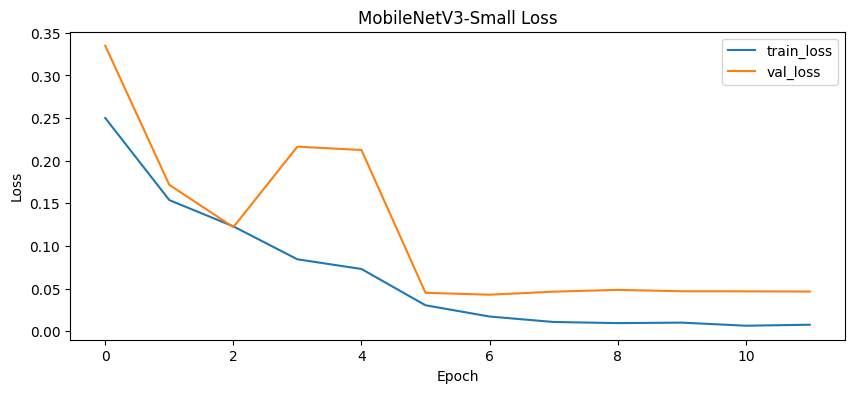

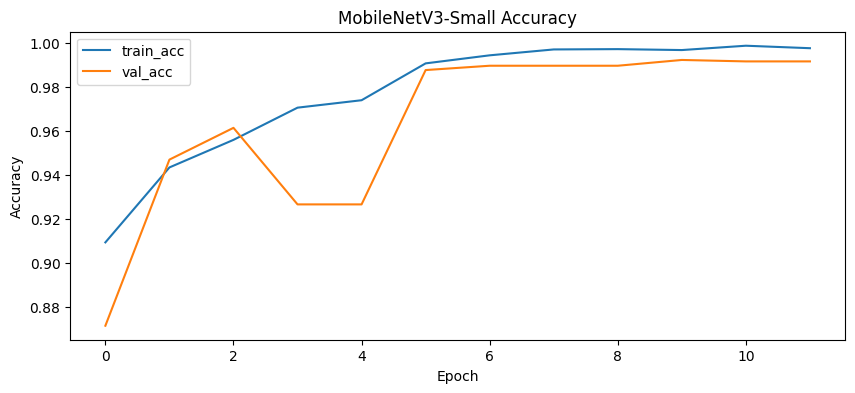


Classification Report:

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       815
    Rot_leaf       0.98      0.99      0.98       201
   Spot_leaf       0.99      0.99      0.99       511

    accuracy                           0.99      1527
   macro avg       0.99      0.99      0.99      1527
weighted avg       0.99      0.99      0.99      1527



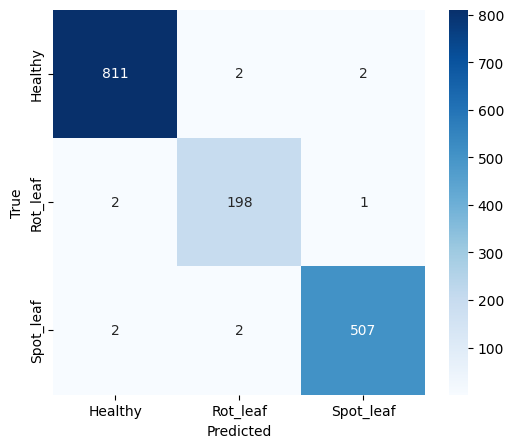


==================== Deployment Metrics ====================
Model size: 5.93 MB
FLOPs: 122.91 MFLOPs | Params: 1.52 M
CPU Latency: 10.42 ms/image
GPU Latency: 5.00 ms/image
RAM Usage: 1610.96 MB


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import psutil
# Install thop if not already installed
!pip install thop
from thop import profile
import statistics
import copy

# ----------------------------
# Device
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ----------------------------
# Helpers
# ----------------------------
def human_bytes(n):
    for unit in ['B','KB','MB','GB']:
        if n < 1024: return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} TB"

def model_size_on_disk(model, fname="temp_model.pth"):
    torch.save(model.state_dict(), fname)
    size = os.path.getsize(fname)
    os.remove(fname)
    return size / (1024*1024)

def count_params(model):
    return sum(p.numel() for p in model.parameters()) / 1e6

def compute_flops(model, input_size=(1,3,224,224), device='cpu'):
    model_copy = copy.deepcopy(model).to(device)
    model_copy.eval()
    dummy = torch.randn(input_size).to(device)
    macs, params = profile(model_copy, inputs=(dummy,), verbose=False)
    flops = macs * 2
    return flops / 1e6, params / 1e6

def measure_latency(model_orig, device='cpu', img_size=224, batch_size=1, runs=100, warmup=10):
    model = copy.deepcopy(model_orig).to(device)
    model.eval()
    inp = torch.randn(batch_size,3,img_size,img_size, device=device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(inp)

    times = []
    with torch.no_grad():
        for _ in range(runs):
            t0 = time.time()
            _ = model(inp)
            if device == "cuda": torch.cuda.synchronize()
            t1 = time.time()
            times.append((t1 - t0) * 1000)

    return statistics.mean(times)

def get_ram_mb():
    return psutil.Process().memory_info().rss / (1024*1024)

def plot_conf_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def plot_training_history(history, title="Training"):
    plt.figure(figsize=(10,4))
    plt.plot(history['train_loss'], label='train_loss')
    plt.plot(history['val_loss'], label='val_loss')
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(history['train_acc'], label='train_acc')
    plt.plot(history['val_acc'], label='val_acc')
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

# ----------------------------
# MobileNetV3-Small
# ----------------------------
def get_mobilenet_v3_small(num_classes):
    model = models.mobilenet_v3_small(pretrained=True)

    # classifier = [Dropout, Linear]
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    return model.to(device)

# ----------------------------
# Training function
# ----------------------------
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=12, device="cpu"):
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_acc = 0.0

    for epoch in range(num_epochs):
        for phase in ["train", "val"]:
            running_loss = 0.0
            running_corrects = 0
            total = 0

            model.train() if phase=="train" else model.eval()

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=="train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase=="train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total += inputs.size(0)

            if phase=="train":
                scheduler.step()

            epoch_loss = running_loss / total
            epoch_acc = running_corrects.double().item() / total

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"Epoch {epoch+1}/{num_epochs} | {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase=="val" and epoch_acc > best_acc:
                best_acc = epoch_acc

    print(f"Training complete. Best val Acc: {best_acc:.4f}")
    return model, history

# ----------------------------
# Evaluation function
# ----------------------------
def evaluate_model(model, test_loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs,1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    plot_conf_matrix(all_labels, all_preds, class_names)


# ----------------------------
# ===========================
# MAIN
# ===========================
# replace train_dataset + dataloaders with your setup

num_classes = len(train_dataset.classes)
model = get_mobilenet_v3_small(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Train
model, history = train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=12, device=device)

# Plot Training
plot_training_history(history, "MobileNetV3-Small")

# Evaluate
evaluate_model(model, dataloaders["test"], train_dataset.classes, device)

# ----------------------------
# Deployment Metrics
# ----------------------------
print("\n==================== Deployment Metrics ====================")
print(f"Model size: {model_size_on_disk(model):.2f} MB")

flops, params = compute_flops(model, (1,3,224,224), device=device)
print(f"FLOPs: {flops:.2f} MFLOPs | Params: {params:.2f} M")

lat_cpu = measure_latency(model, device="cpu")
print(f"CPU Latency: {lat_cpu:.2f} ms/image")

if device == "cuda":
    lat_gpu = measure_latency(model, device="cuda")
    print(f"GPU Latency: {lat_gpu:.2f} ms/image")

print(f"RAM Usage: {get_ram_mb():.2f} MB")
print("================================================================")